# 1、字符串输出解析器 StrOutputParser

StrOutputParser：把 AIMessage 转成普通字符串

In [3]:
# 1、获取大模型
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.output_parsers import StrOutputParser, XMLOutputParser

import os
import dotenv
from langchain_core.utils import pre_init
from langchain_openai import ChatOpenAI

dotenv.load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

chat_model = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 2、调用大模型
response = chat_model.invoke("什么是大语言模型？")
# print(type(response))   #AIMessage

#3、如何获取一个字符串的输出结果呢？
# 方式1：自己调用输出结果的content
# print(response.content)

# 方式2：使用StrOutputParser
parser = StrOutputParser()
str_response = parser.invoke(response)
print("===== 原始模型返回 =====")
print(type(response))
print(response)

print("\n===== Parser处理后 =====")
print(type(str_response))
print(str_response)


===== 原始模型返回 =====
<class 'langchain_core.AIMessage'>
AIMessage(content='大语言模型是能够理解、分析、生成和回答人类问题的大型计算机程序。它们可以模仿人类的语言技能，如说话、写作、翻译、阅读理解等。大语言模型通常由计算机科学和人工智能技术共同开发，能够处理大规模的数据集，进行复杂的计算和推理，从而能够提供高质量的语言服务。', additional_kwargs={})

===== Parser处理后 =====
<class 'str'>
大语言模型是能够理解、分析、生成和回答人类问题的大型计算机程序。它们可以模仿人类的语言技能，如说话、写作、翻译、阅读理解等。大语言模型通常由计算机科学和人工智能技术共同开发，能够处理大规模的数据集，进行复杂的计算和推理，从而能够提供高质量的语言服务。


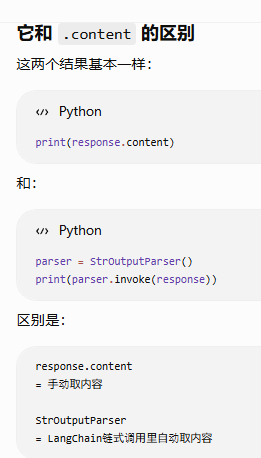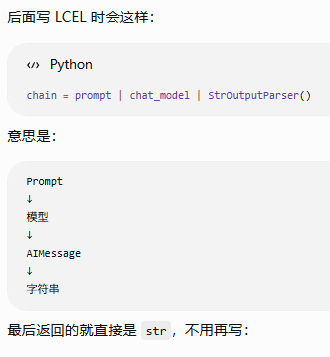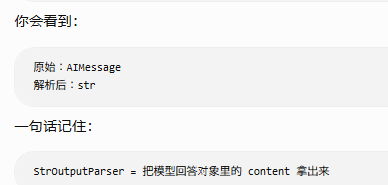

# 2、JsonOutputParser : Json输出解析器

方式1：

In [6]:
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import ChatPromptTemplate

chat_model = ChatOpenAI(model="qwen2.5-coder:1.5b")

chat_prompt_template = ChatPromptTemplate.from_messages([
    ("system", "你是一个靠谱的{role}"),
    ("human", "{question}")
])

# 正确的：
prompt = chat_prompt_template.invoke(
    input={"role": "人工智能专家", "question": "人工智能用英文怎么说？问题用q表示，答案用a表示，返回一个JSON格式的数据"})

# 错误的：
# prompt = chat_prompt_template.invoke(input={"role":"人工智能专家","question":"人工智能用英文怎么说？"})

response = chat_model.invoke(prompt)
# print(response.content)

# 获取一个JsonOutputParser的实例
parser = JsonOutputParser()

json_result = parser.invoke(response)
print("===== 原始模型返回 =====")
print(type(response))
print(response)

print("\n===== content =====")
print(type(response.content))
print(response.content)

print("\n===== Json解析后 =====")
print(type(json_result))
print(json_result)

print("\n===== 取值 =====")
print(json_result["q"])
print(json_result["a"])

===== 原始模型返回 =====
<class 'langchain_core.AIMessage'>
AIMessage(content=' ```json\n{\n  "q": "为什么你会使用人工智能？",\n  "a": "我使用人工智能是因为它可以完成复杂的任务，加速决策过程，并提高工作效率。"\n}\n```', additional_kwargs={})

===== content =====
<class 'str'>
 ```json
{
  "q": "为什么你会使用人工智能？",
  "a": "我使用人工智能是因为它可以完成复杂的任务，加速决策过程，并提高工作效率。"
}
```

===== Json解析后 =====
<class 'dict'>
{'q': '为什么你会使用人工智能？', 'a': '我使用人工智能是因为它可以完成复杂的任务，加速决策过程，并提高工作效率。'}

===== 取值 =====
为什么你会使用人工智能？
我使用人工智能是因为它可以完成复杂的任务，加速决策过程，并提高工作效率。


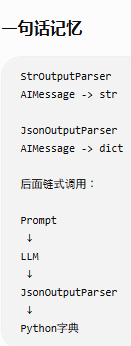

方式2：

举例1：

In [9]:
parser = JsonOutputParser()

instructions = parser.get_format_instructions()

print("===== Parser类型 =====")
print(type(parser))

print("\n===== 格式要求 =====")
print(instructions)

===== Parser类型 =====
<class 'langchain_core.JsonOutputParser'>

===== 格式要求 =====
Return a valid JSON object such as {"question": "...", "answer": "..."}.


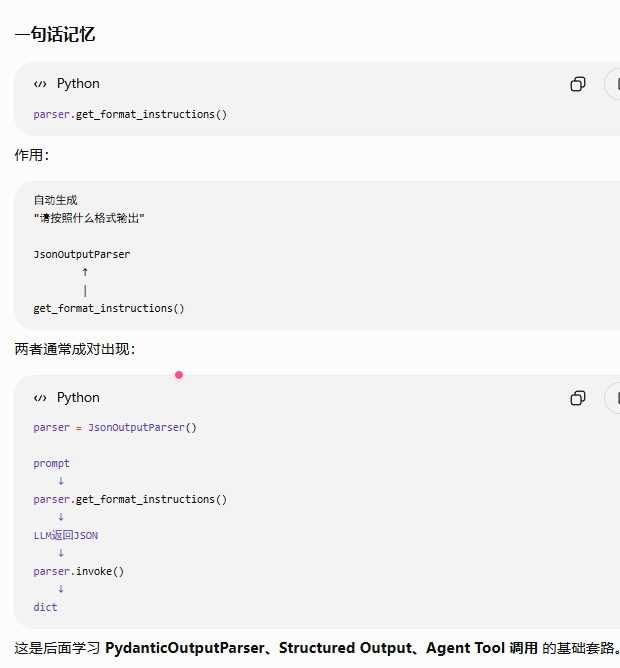

举例2：

In [11]:
# 引入依赖包
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import PromptTemplate

# 初始化语言模型
chat_model = ChatOpenAI(model="qwen2.5-coder:1.5b")

joke_query = "告诉我一个笑话。"

# 定义Json解析器
parser = JsonOutputParser()

#以PromptTemplate为例
prompt_template = PromptTemplate.from_template(
    template="回答用户的查询\n 满足的格式为{format_instructions}\n 问题为{question}\n",
    partial_variables={"format_instructions": parser.get_format_instructions()},
)

prompt = prompt_template.invoke(input={"question": joke_query})
response = chat_model.invoke(prompt)
#print(response)

json_result = parser.invoke(response)
#print(json_result)
print("===== Prompt =====")
print(prompt)

print("\n===== AI原始返回 =====")
print(response.content)

print("\n===== Json解析后 =====")
print(json_result)

print("\n===== 类型 =====")
print(type(json_result))

===== Prompt =====
回答用户的查询
 满足的格式为Return a valid JSON object such as {"question": "...", "answer": "..."}.
 问题为告诉我一个笑话。


===== AI原始返回 =====
Here's a valid JSON object for the joke:
```json
{
  "question": "Why did the tomato turn red?",
  "answer": "Because it saw the salad dressing!"
}
```

===== Json解析后 =====
{'question': 'Why did the tomato turn red?', 'answer': 'Because it saw the salad dressing!'}

===== 类型 =====
<class 'dict'>


In [13]:
parser = JsonOutputParser()

prompt = PromptTemplate.from_template(
"""
你是一个笑话大师

{format_instructions}

问题:
{question}
"""
)

chain = (
    prompt
    | chat_model
    | parser
)

result = chain.invoke({
    "question":"告诉我一个笑话",
    "format_instructions":
        parser.get_format_instructions()
})

print(result)
print(type(result))

{'text': '好的，我来给你讲一个笑话吧：\n\n有一天，一只狐狸问另一只狐狸：“你怎么叫？”另一只狐狸回答：“我叫狐狸。”狐狸问：“那你叫什么东西？”另一只狐狸回答：“我叫狐狸。”狐狸问：“那你就叫”狐狸。“狐狸。”另一只狐狸回答：“那我就叫”狐狸。“哦，那你就叫狐狸，那你就叫狐狸！”狐狸问：“那你就叫”狐狸。“狐狸。”另一只狐狸回答：“那我就叫”狐狸。“哦，那你就叫狐狸，那你就叫狐狸！”狐狸问：“这你叫”狐狸。“狐狸！”另一只狐狸回答：“那我就叫”狐狸。“哦，那你就叫狐狸，那你就叫狐狸！”狐狸问：“这你叫”狐狸。“狐狸！”\n\n哈哈，这就是笑话。'}
<class 'dict'>


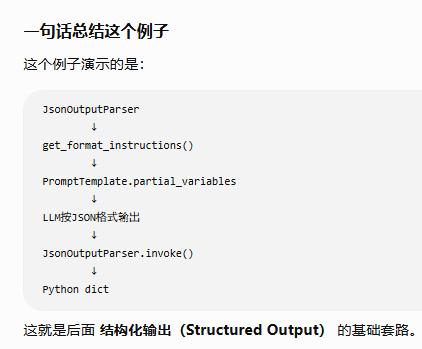

知识的拓展： |

In [17]:
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import ChatPromptTemplate

chat_model = ChatOpenAI(model="qwen2.5-coder:1.5b")

chat_prompt_template = ChatPromptTemplate.from_messages([
    ("system", "你是一个靠谱的{role}"),
    ("human", "{question}")
])

# 获取一个JsonOutputParser的实例
parser = JsonOutputParser()

# 写法1：
# prompt = chat_prompt_template.invoke(input={"role":"人工智能专家","question":"人工智能用英文怎么说？问题用q表示，答案用a表示，返回一个JSON格式的数据"})
#
# response = chat_model.invoke(prompt)
#
# json_result = parser.invoke(response)
# print(json_result)


# 写法2：
chain = chat_prompt_template | chat_model | parser
json_result1 = chain.invoke(
    input={"role": "人工智能专家", "question": "人工智能用英文怎么说？问题用q表示，答案用a表示，返回一个JSON格式的数据"})
#print(json_result1)
print("===== Chain对象 =====")
print(chain)

print("\n===== 返回结果 =====")
print(json_result1)

print("\n===== 类型 =====")
print(type(json_result1))

===== Chain对象 =====

===== 返回结果 =====
{'question': '人工智能用英文怎么说？', 'answer': '人工智能（Artificial Intelligence, AI）是一种模拟人类智能的计算方法和系统。它利用人工智能技术进行问题解决、学习和预测，可以用于各种任务，如语音识别、图像识别、自然语言处理、机器翻译等。.'}

===== 类型 =====
<class 'dict'>


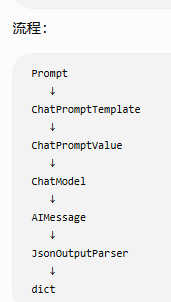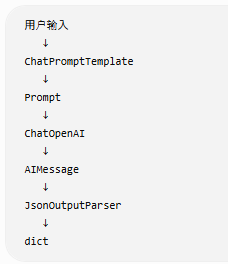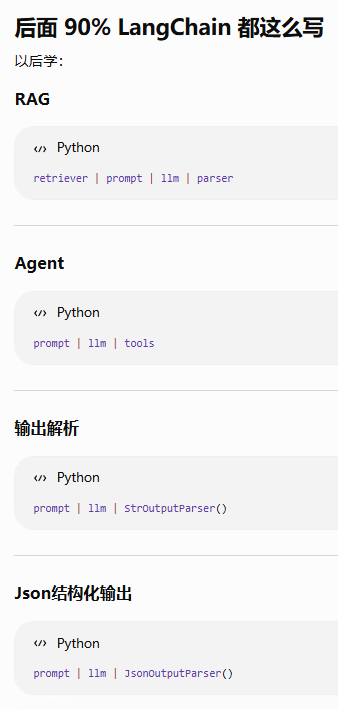

针对于举例2

In [22]:
parser = JsonOutputParser()

prompt_template = PromptTemplate.from_template(
    template="""
你需要回答用户的问题，并且只返回 JSON。

不要输出解释。
不要输出 Markdown。
不要照抄示例里的省略号。
必须用真实内容替换 question 和 answer。

格式要求：
{format_instructions}

用户问题：
{question}
""",
    partial_variables={
        "format_instructions": parser.get_format_instructions()
    },
)

chain = prompt_template | chat_model | parser

json_result = chain.invoke({
    "question": "告诉我一个笑话。"
})

print("===== 返回类型 =====")
print(type(json_result))

print("\n===== 完整JSON =====")
print(json_result)

print("\n===== 所有键 =====")
print(list(json_result.keys()))

print("\n===== Question =====")
print(json_result["question"])

print("\n===== Answer =====")
print(json_result["answer"])

===== 返回类型 =====
<class 'dict'>

===== 完整JSON =====
{'question': '我有一个朋友总是对我的问题感到疑惑。有一天，我问他‘你为什么总是问同样的问题呢？’他回答：“因为我是被这些问题困扰一辈子的啊！”', 'answer': '他真是个非常睿智的人。'}

===== 所有键 =====
['question', 'answer']

===== Question =====
我有一个朋友总是对我的问题感到疑惑。有一天，我问他‘你为什么总是问同样的问题呢？’他回答：“因为我是被这些问题困扰一辈子的啊！”

===== Answer =====
他真是个非常睿智的人。


# 3、XMLOutputParser XML输出解析器的使用

举例1：自己在提示词模板中写明使用XML格式

In [27]:
chat_model = ChatOpenAI(model="qwen2.5-coder:1.5b")

actor_query = "周星驰的简单电影记录"

response = chat_model.invoke(
    f"""
请生成{actor_query}。

要求：
1. 只输出 XML
2. 不要输出 Markdown
3. 不要使用 ```xml
4. 所有电影信息必须放在 <movie></movie> 标签中

格式示例：
<movie>
    <title>电影名称</title>
    <actor>演员名称</actor>
    <summary>电影简介</summary>
</movie>
"""
)

print("===== 原始返回类型 =====")
print(type(response))

print("\n===== XML内容 =====")
print(response.content)

===== 原始返回类型 =====
<class 'langchain_core.AIMessage'>

===== XML内容 =====
```xml
<movie>
    <title>周星驰电影</title>
    <actor>周星驰</actor>
    <summary>描述周星驰电影经典动作及喜剧片段，感受他独特的艺术魅力。</summary>
</movie>
```


举例2：

In [34]:
from langchain_core.output_parsers.xml import XMLOutputParser

parser = XMLOutputParser()
xml_text = response.content

# 清理 Markdown 代码块
xml_text = xml_text.replace("```xml", "").replace("```", "").strip()

print("===== 清理后的XML =====")
print(xml_text)

result = parser.invoke(xml_text)

print("\n===== 解析结果 =====")
print(result)
print(type(result))

===== 清理后的XML =====
<movie>
    <title>周星驰电影</title>
    <actor>周星驰</actor>
    <summary>描述周星驰电影经典动作及喜剧片段，感受他独特的艺术魅力。</summary>
</movie>

===== 解析结果 =====
<Element 'movie' at 0x00000274B56DA200>
<class 'xml.etree.ElementTree.Element'>


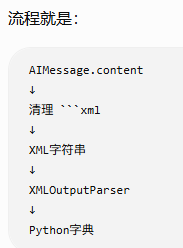

使用parser.get_format_instructions()结构实现：

In [40]:
# 1.导入相关包
from langchain_core.output_parsers import XMLOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

# 2. 初始化语言模型
chat_model = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 3.测试模型的xml解析效果
actor_query = "生成汤姆·汉克斯的简短电影记录,使用中文回复"

# 4.定义XMLOutputParser对象
parser = XMLOutputParser()

# 5. 生成提示词模板
prompt_template1 = PromptTemplate.from_template(
    template="用户的问题：{query}\n使用的格式：{format_instructions}"
)

prompt_template2 = prompt_template1.partial(format_instructions=parser.get_format_instructions())


response = chat_model.invoke(
    prompt_template2.invoke(
        input={"query": actor_query}
    )
)

print("===== XML原始内容 =====")
print(response.content)

print("===== parser类型 =====")
print(type(parser))

print("\n===== response类型 =====")
print(type(response))

xml_result = parser.invoke(response)

print("\n===== xml_result类型 =====")
print(type(xml_result))

print("\n===== xml_result内容 =====")
print(xml_result)


===== XML原始内容 =====
Mock response (qwen2.5-coder:1.5b, bda6f3ab494de6b4): 用户的问题：生成汤姆·汉克斯的简短电影记录,使用中文回复
使用的格式：Return a valid XML document.
===== parser类型 =====
<class 'langchain_core.XMLOutputParser'>

===== response类型 =====
<class 'langchain_core.AIMessage'>

===== xml_result类型 =====
<class 'xml.etree.ElementTree.Element'>

===== xml_result内容 =====
<Element 'text' at 0x00000274B56D8C20>


In [41]:
xml_result = parser.invoke(response)
print(xml_result)

<Element 'text' at 0x00000274B56D8AE0>


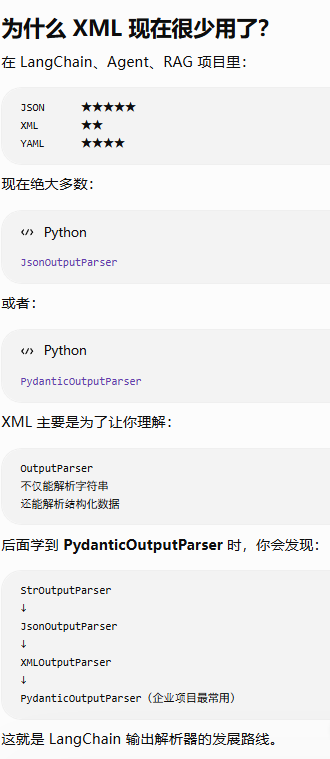

# 4、列表解析器 CommaSeparatedListOutputParser

举例1：这个解析器是 OutputParser 里面最简单的一个，非常适合理解 Parser 的本质：字符串 → Python对象。

In [ ]:
from langchain_core.output_parsers import CommaSeparatedListOutputParser

parser = CommaSeparatedListOutputParser()

print("===== 格式要求 =====")
print(parser.get_format_instructions())

text = "大象,猩猩,狮子"

print("\n===== 原始字符串 =====")
print(text)
# print("\n===== 解析 =====")
result = parser.parse(text)

print("\n===== 解析结果 =====")
print(result)

print("\n===== 类型 =====")
print(type(result))

print("\n===== 遍历列表 =====")
for i, animal in enumerate(result, start=1):
    print(f"{i}. {animal}")

===== 格式要求 =====
Return a comma-separated list.

===== 原始字符串 =====
大象,猩猩,狮子

===== 解析结果 =====
['大象', '猩猩', '狮子']

===== 类型 =====
<class 'list'>

===== 遍历列表 =====
1. 大象
2. 猩猩
3. 狮子


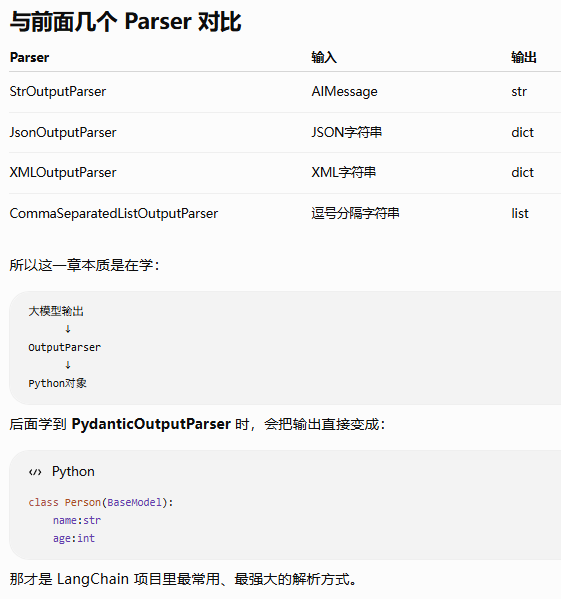

举例2：

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from langchain.output_parsers import CommaSeparatedListOutputParser

chat_model = ChatOpenAI(model="qwen2.5-coder:1.5b")

output_parser = CommaSeparatedListOutputParser()

chat_prompt = PromptTemplate.from_template(
    """
生成5个关于{text}的中文列表。

要求：
1. 只输出中文名称
2. 使用逗号分隔
3. 不要编号
4. 不要加引号
5. 不要解释

{format_instructions}
""",
    partial_variables={
        "format_instructions": output_parser.get_format_instructions()
    }
)

chain = chat_prompt | chat_model | output_parser
#  print("===== 返回结果 =====")
res = chain.invoke({"text": "电影"})

print("===== 返回结果 =====")
print(res)

print("\n===== 返回类型 =====")
print(type(res))

print("\n===== 遍历结果 =====")
for i, item in enumerate(res, 1):
    print(f"{i}. {item}")

===== 返回结果 =====
['肖申克的救赎', '泰坦尼克号', '复仇者联盟', '星际穿越', '霸王龙凯特']

===== 返回类型 =====
<class 'list'>

===== 遍历结果 =====
1. 肖申克的救赎
2. 泰坦尼克号
3. 复仇者联盟
4. 星际穿越
5. 霸王龙凯特


# 5、日期解析器 DatetimeOutputParser

举例1：

In [46]:
from langchain.output_parsers import DatetimeOutputParser

output_parser = DatetimeOutputParser()

format_instructions = output_parser.get_format_instructions()
print(format_instructions)

Return a datetime in ISO 8601 format, for example 2026-06-17T00:00:00.


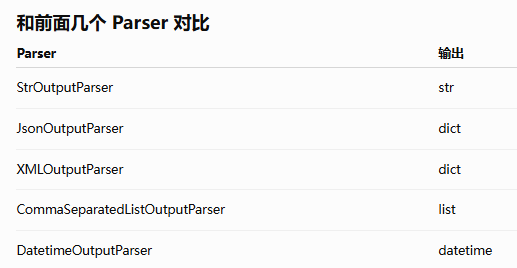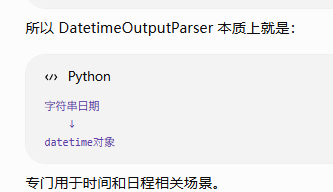

举例2：


In [47]:
from langchain_openai import ChatOpenAI
from langchain.prompts.chat import HumanMessagePromptTemplate
from langchain_core.prompts import ChatPromptTemplate
from langchain.output_parsers import DatetimeOutputParser

chat_model = ChatOpenAI(model="qwen2.5-coder:1.5b")


chat_prompt = ChatPromptTemplate.from_messages([
    ("system","{format_instructions}"),
    ("human", "{request}")
])

output_parser = DatetimeOutputParser()

# 方式1：
# model_request = chat_prompt.format_messages(
#     request="中华人民共和国是什么时候成立的",
#     format_instructions=output_parser.get_format_instructions()
# )

# response = chat_model.invoke(model_request)
# result = output_parser.invoke(response)
# print(result)
# print(type(result))

# 方式2：
chain = chat_prompt | chat_model | output_parser
resp = chain.invoke({"request":"中华人民共和国是什么时候成立的",
                     "format_instructions":output_parser.get_format_instructions()})
print(resp)
print(type(resp))

中华人民共和国的成立时间是在1949年10月1日星期五。
<class 'str'>


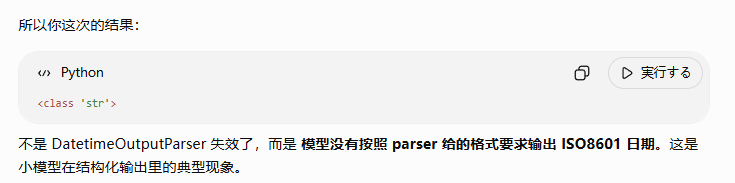